In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV
from scipy.stats import chi2_contingency

# Configurando o estilo dos gráficos para o portfólio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carregar o dataset (ajuste o caminho se necessário)
df = pd.read_csv('../data/raw/telco.csv')

# Renomear as colunas substituindo espaços por nada (ou por underlines, se preferir)
# Aqui vamos deixar tudo junto para bater com o padrão clássico
df.columns = df.columns.str.replace(' ', '')

print("--- Colunas Padronizadas ---")
print(df.columns.tolist())


# Tratando os nulos com base na lógica de negócio
df['ChurnCategory'] = df['ChurnCategory'].fillna('None (Active Customer)')
df['ChurnReason'] = df['ChurnReason'].fillna('None (Active Customer)')
df['InternetType'] = df['InternetType'].fillna('No Internet Service')
df['Offer'] = df['Offer'].fillna('No Offer')

# Rodando novamente a checagem universal para garantir o sucesso da limpeza
print("--- Quantidade de nulos restantes no dataset ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Colunas Padronizadas ---
['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 'Dependents', 'NumberofDependents', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter', 'ReferredaFriend', 'NumberofReferrals', 'TenureinMonths', 'Offer', 'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines', 'InternetService', 'InternetType', 'AvgMonthlyGBDownload', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'CLTV', 'ChurnCategory', 'ChurnReason']
--- Quantidade de nulos restantes no dataset ---
Series([], dtype: int64)


In [2]:
# Aplicando a correção de texto para float na coluna agora padronizada
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

print("\n--- Quantidade de valores nulos encontrados em TotalCharges ---")
print(df['TotalCharges'].isnull().sum())


--- Quantidade de valores nulos encontrados em TotalCharges ---
0


--- Proporção da Variável Alvo (Churn) ---
Não cancelaram (No): 73.46%
Cancelaram (Yes): 26.54%



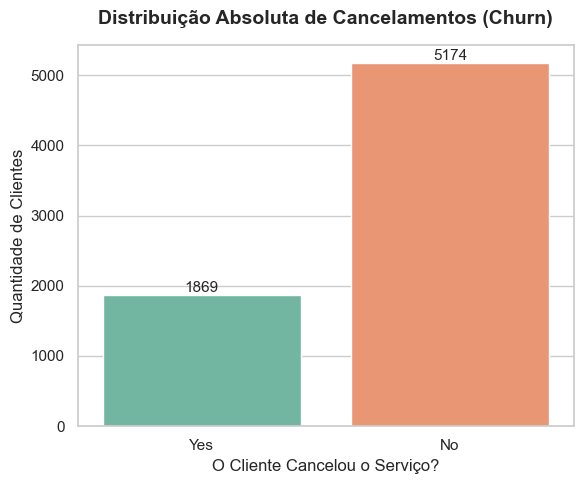

In [3]:
# Calcular a porcentagem exata de Churn no dataset
churn_counts = df['ChurnLabel'].value_counts(normalize=True) * 100
print("--- Proporção da Variável Alvo (Churn) ---")
print(f"Não cancelaram (No): {churn_counts['No']:.2f}%")
print(f"Cancelaram (Yes): {churn_counts['Yes']:.2f}%\n")

# Plotar o gráfico de barras
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='ChurnLabel', data=df, hue='ChurnLabel', palette='Set2', legend=False)

# Adicionar os títulos com a mentalidade de relatório executivo
plt.title('Distribuição Absoluta de Cancelamentos (Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('O Cliente Cancelou o Serviço?', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Adicionar as quantidades em cima de cada barra para facilitar a leitura visual
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

In [4]:
# Mostrar o resumo estatístico apenas das colunas que o Pandas entendeu como NÚMERO
print("--- Resumo Estatístico das Variáveis Numéricas ---")
print(df.describe().T)

--- Resumo Estatístico das Variáveis Numéricas ---
                                count          mean           std  \
Age                            7043.0     46.509726     16.750352   
NumberofDependents             7043.0      0.468692      0.962802   
ZipCode                        7043.0  93486.070567   1856.767505   
Latitude                       7043.0     36.197455      2.468929   
Longitude                      7043.0   -119.756684      2.154425   
Population                     7043.0  22139.603294  21152.392837   
NumberofReferrals              7043.0      1.951867      3.001199   
TenureinMonths                 7043.0     32.386767     24.542061   
AvgMonthlyLongDistanceCharges  7043.0     22.958954     15.448113   
AvgMonthlyGBDownload           7043.0     20.515405     20.418940   
MonthlyCharge                  7043.0     64.761692     30.090047   
TotalCharges                   7043.0   2280.381264   2266.220462   
TotalRefunds                   7043.0      1.962182 

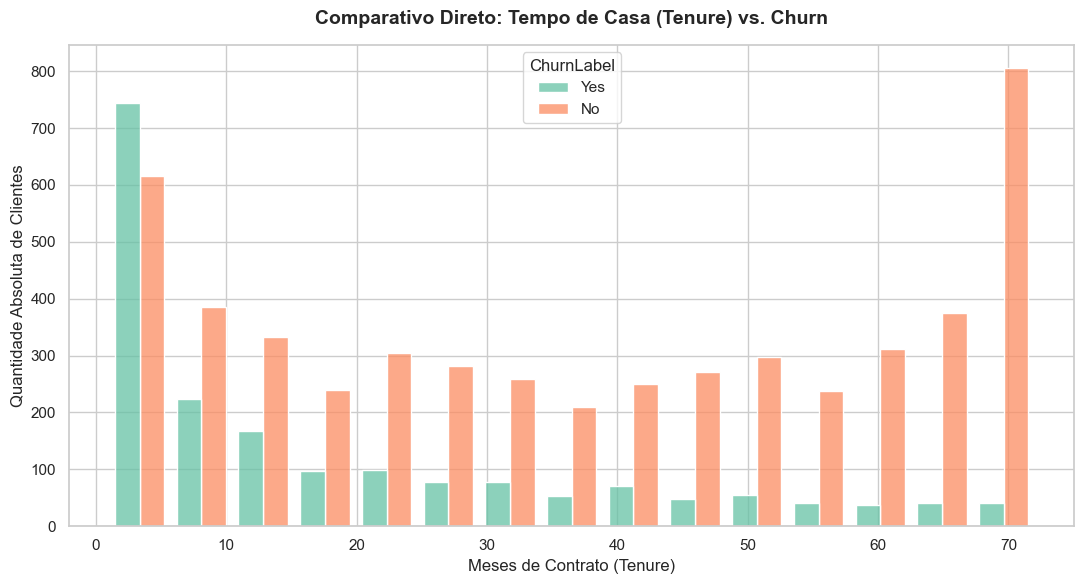

In [5]:
plt.figure(figsize=(11, 6))

# Mudamos 'multiple' de 'stack' (empilhado) para 'dodge' (lado a lado)
# E limitamos os bins para ficar mais fácil de enxergar mês a mês no início
sns.histplot(data=df, x='TenureinMonths', hue='ChurnLabel', multiple='dodge', palette='Set2', shrink=0.8)

plt.title('Comparativo Direto: Tempo de Casa (Tenure) vs. Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Meses de Contrato (Tenure)', fontsize=12)
plt.ylabel('Quantidade Absoluta de Clientes', fontsize=12)

plt.tight_layout()
plt.show()

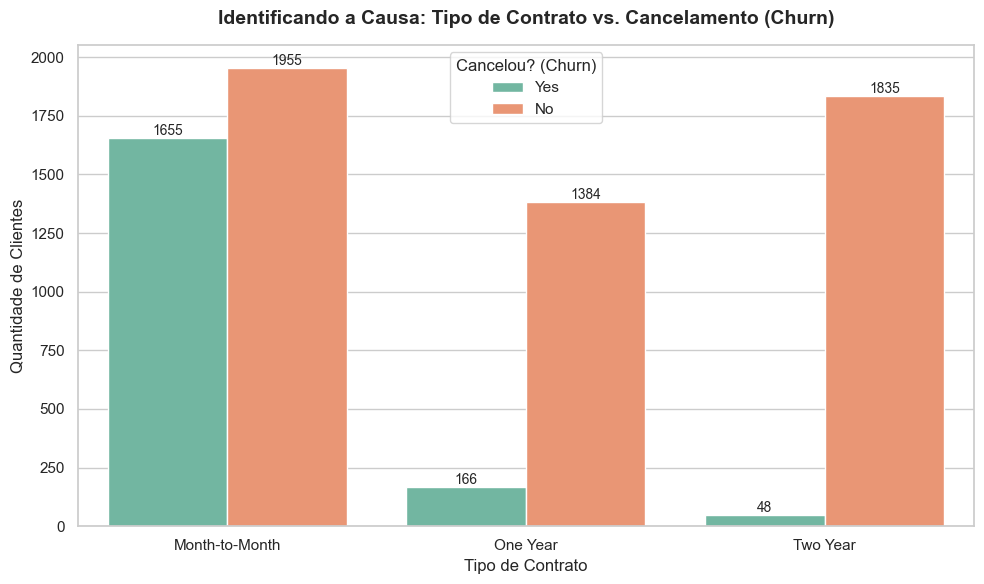

In [6]:
plt.figure(figsize=(10, 6))

# Cruzando o Tipo de Contrato (Contract) com o Churn
# Ajuste o nome da coluna 'Contract' se no seu dataset estiver diferente (ex: ContractType)
ax = sns.countplot(data=df, x='Contract', hue='ChurnLabel', palette='Set2')

plt.title('Identificando a Causa: Tipo de Contrato vs. Cancelamento (Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.legend(title='Cancelou? (Churn)', loc='best')

# Adicionando os valores nas barras para termos precisão numérica
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Evita plotar labels em barras vazias
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

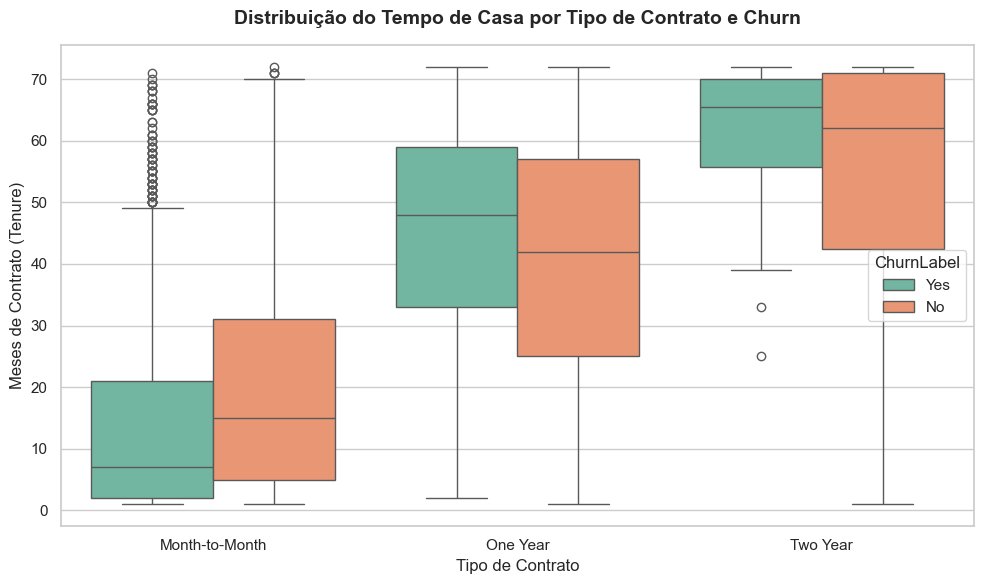

In [7]:
plt.figure(figsize=(10, 6))

# Boxplot para ver a distribuição de meses (TenureMonths) para cada tipo de contrato, dividido por Churn
sns.boxplot(data=df, x='Contract', y='TenureinMonths', hue='ChurnLabel', palette='Set2')

plt.title('Distribuição do Tempo de Casa por Tipo de Contrato e Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Meses de Contrato (Tenure)', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
# Transformando a variável alvo 'Churn' em numérica (0 e 1)
# Ajuste para 'ChurnLabel' ou o nome exato da sua coluna se necessário
df['ChurnLabel'] = df['ChurnLabel'].map({'Yes': 1, 'No': 0})

#  Vamos checar se a transformação funcionou olhando a proporção novamente
print("--- Variável Alvo Convertida para Numérica ---")
print(df['ChurnLabel'].value_counts())

--- Variável Alvo Convertida para Numérica ---
ChurnLabel
0    5174
1    1869
Name: count, dtype: int64


In [9]:
# 1. Lista refinada com TODAS as colunas comportamentais e de perfil reais
colunas_comportamentais = [
    # Perfil Demográfico Avançado
    'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 
    'Dependents', 'NumberofDependents', 
    
    # Comportamento de Engajamento/Rede
    'ReferredaFriend', 'NumberofReferrals', 'TenureinMonths', 'Offer',
    
    # Serviços e Consumo Técnico (O que ele usa e o quanto usa)
    'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines', 
    'InternetService', 'InternetType', 'AvgMonthlyGBDownload', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 
    'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 
    'StreamingMusic', 'UnlimitedData',
    
    # Contrato e Financeiro Dinâmico
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge', 
    'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 
    'TotalLongDistanceCharges', 'TotalRevenue',
    
    # Percepção do Cliente (Métrica de negócio fortíssima)
    'SatisfactionScore', 'CLTV'
]

# Vazamentos de dados e IDs que DEVEM ser excluídos do treinamento do mapa
# 'ChurnCategory', 'ChurnReason', 'ChurnScore', 'ChurnLabel', 'CustomerStatus'

# Criando a matriz de features brutas com o novo lineup de colunas
X_raw = df[colunas_comportamentais].copy()

# Ajustando a variável alvo para o nome real do seu dataset
y = df['ChurnLabel'].values

print("--- Dataset Pronto para a Engenharia de Recursos ---")
print(f"Total de instâncias (Clientes): {X_raw.shape[0]}")
print(f"Total de variáveis comportamentais: {X_raw.shape[1]}")

--- Dataset Pronto para a Engenharia de Recursos ---
Total de instâncias (Clientes): 7043
Total de variáveis comportamentais: 36


In [10]:

# 1. Identificar o que é coluna de texto (categórica) e o que é número
colunas_categoricas = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
colunas_numericas = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Aplicar One-Hot Encoding nas categóricas (transforma texto em 0 e 1)
X_encoded = pd.get_dummies(X_raw, columns=colunas_categoricas, drop_first=True)

# 3. Normalizar todas as colunas para a escala [0, 1] (Essencial para o Kohonen)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("--- Dados Prontos para o Mapa de Kohonen ---")
print(f"Formato original: {X_raw.shape}")
print(f"Formato após codificação (Matriz para a Rede): {X_scaled.shape}")

--- Dados Prontos para o Mapa de Kohonen ---
Formato original: (7043, 36)
Formato após codificação (Matriz para a Rede): (7043, 44)


In [11]:
# 1. Definir dimensões da grade (20x20 = 400 neurônios)
tamanho_x = 40
tamanho_y = 40
input_len = X_scaled.shape[1] # Número de features na nossa matriz transformada

# 2. Inicializar a rede de Kohonen
# sigma: raio dos vizinhos na grade | learning_rate: taxa de aprendizado inicial
som = MiniSom(x=tamanho_x, y=tamanho_y, input_len=input_len, 
              sigma=0.70, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)

# Opcional: Inicialização PCA dos pesos para convergência mais rápida
som.pca_weights_init(X_scaled)

print("--- Iniciando o Treinamento do Mapa de Kohonen ---")
# Treinamento com 5000 iterações (ajuste conforme necessário para convergência)
som.train_random(data=X_scaled, num_iteration=5000, verbose=True)
print("\nTreinamento concluído com sucesso!")

--- Iniciando o Treinamento do Mapa de Kohonen ---
 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 1.4871886431055936

Treinamento concluído com sucesso!


In [82]:
# 1. Avaliando a Performance Matemática do Mapa de Kohonen
# (Supondo que você usou a biblioteca MiniSom, o objeto 'som' tem esses métodos nativos)
try:
    erro_quantizacao = som.quantization_error(X_scaled_clean)
    erro_topologico = som.topographic_error(X_scaled_clean)

    print("=================== PERFORMANCE DO MAPA DE KOHONEN ===================")
    print(f"Erro de Quantização (Fidelidade dos Perfis): {erro_quantizacao:.4f}")
    print(f"Erro Topológico (Preservação da Vizinhança): {erro_topologico*100:.2f}%")
    print("=======================================================================\n")
except NameError:
    print("Objeto 'som' ou base normalizada não encontrados com esses nomes. Ajuste se necessário.\n")

# 2. Preparando os dados com a Estratégia B (Injetar a Geografia do SOM no XGBoost)
df_hibrido = df_clean_pipeline.copy()

# Aqui garantimos que X_som e Y_som que o Kohonen gerou entrem como variáveis preditivas puras!
# Vamos deixar o XGBoost usar a inteligência espacial do Kohonen.
X_hibrido = df_hibrido.drop(columns=[
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity' # Mantemos a blindagem contra vazamentos!
])

# Encoding das categóricas remanescentes
cols_cat_hibrido = X_hibrido.select_dtypes(include=['object', 'category']).columns.tolist()
X_hibrido_encoded = pd.get_dummies(X_hibrido, columns=cols_cat_hibrido, drop_first=True)

print("Estrutura híbrida criada. Colunas de coordenadas incluídas:")
print([col for col in X_hibrido_encoded.columns if 'som' in col.lower()])

=================== PERFORMANCE DO MAPA DE KOHONEN ===================
Erro de Quantização (Fidelidade dos Perfis): 1.4872
Erro Topológico (Preservação da Vizinhança): 65.14%

Estrutura híbrida criada. Colunas de coordenadas incluídas:
[]


--- Saneamento de Amostras para o Gráfico ---
Amostras originais: 7043
Amostras válidas após remover nulos ocultos: 7043



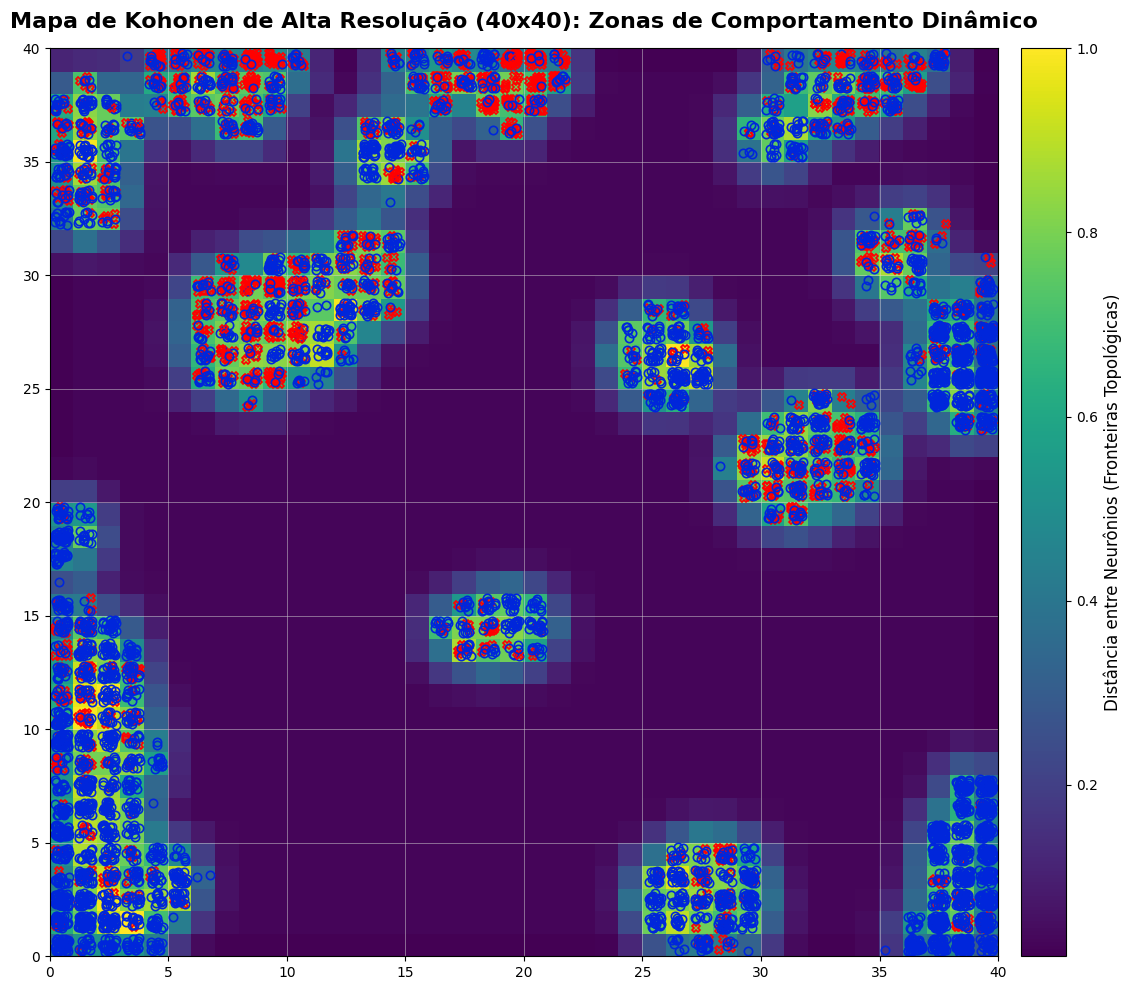

In [12]:
# 1. Identificar quais linhas em 'y' NÃO são nulas (ou seja, são 0 ou 1 válidos)
# Se 'y' veio como um array de objetos/strings com NaNs, removemos os inválidos
linhas_validas = ~pd.isna(y)

# 2. Filtrar tanto a matriz de entrada quanto o vetor alvo para manter apenas dados válidos
X_scaled_clean = X_scaled[linhas_validas]
y_clean = y[linhas_validas].astype(int) # Agora a conversão para inteiro vai funcionar perfeitamente

print(f"--- Saneamento de Amostras para o Gráfico ---")
print(f"Amostras originais: {len(y)}")
print(f"Amostras válidas após remover nulos ocultos: {len(y_clean)}\n")


# Garante o uso do tema claro padrão
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 10))

# Plotando a U-Matrix com viridis no fundo claro
cax = ax.pcolor(som.distance_map().T, cmap='viridis') 
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label('Distância entre Neurônios (Fronteiras Topológicas)', fontsize=12)

# Marcadores com cores de alto contraste para o fundo viridis
markers = ['o', 'X']
colors = ['#0026db', '#ff0000'] # Azul escuro para Ativo, Vermelho vivo para Churn

rng = np.random.default_rng(42)

for i, x in enumerate(X_scaled_clean):
    w = som.winner(x)
    
    # Efeito Jitter para espalhar os pontos dentro do mesmo neurônio
    deslocamento_x = rng.uniform(-0.3, 0.3)
    deslocamento_y = rng.uniform(-0.3, 0.3)
    
    ax.plot(w[0] + 0.5 + deslocamento_x, w[1] + 0.5 + deslocamento_y, markers[y_clean[i]], 
             markerfacecolor='none', markeredgecolor=colors[y_clean[i]], 
             markersize=6, markeredgewidth=1.2)

ax.set_title('Mapa de Kohonen de Alta Resolução (40x40): Zonas de Comportamento Dinâmico', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlim(0, tamanho_x)
ax.set_ylim(0, tamanho_y)

# Grade cinza clara clássica de engenharia
ax.grid(True, which='both', color='#d3d3d3', linestyle='-', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [48]:
# 1. Isolar a região norte definida pelo Kohonen
regiao_norte = df_analise[df_analise['Y_som'] >= 20]

print(f"===============================================================")
print(f"   RELATÓRIO DE VARIANÇA GLOBAL - HEMISFÉRIO NORTE (Y >= 20)   ")
print(f"===============================================================\n")

# --- PARTE 1: VARIÁVEIS NUMÉRICAS ---
print("--- 1. COMPORTAMENTO DAS VARIÁVEIS NUMÉRICAS (MÉDIAS) ---")
cols_numericas = regiao_norte.select_dtypes(include=[np.number]).columns.tolist()
# Removemos as coordenadas do SOM para não poluir
cols_numericas = [c for c in cols_numericas if c not in ['X_som', 'Y_som', 'ZipCode', 'Latitude', 'Longitude']]

print(regiao_norte.groupby('CustomerStatus')[cols_numericas].mean().T)
print("\n" + "="*63 + "\n")

# --- PARTE 2: VARIÁVEIS CATEGÓRICAS ---
print("--- 2. DISTRIBUIÇÃO PERCENTUAL DAS VARIÁVEIS CATEGÓRICAS ---")
cols_categoricas = regiao_norte.select_dtypes(include=['object', 'category']).columns.tolist()
# Removemos o próprio status que é o nosso agrupador
if 'CustomerStatus' in cols_categoricas: cols_categoricas.remove('CustomerStatus')
# Removemos IDs ou textos longos irrelevantes para o agrupamento direto
for descarte in ['CustomerID', 'Country', 'State', 'City', 'Quarter', 'ChurnLabel', 'ChurnCategory', 'ChurnReason']:
    if descarte in cols_categoricas: cols_categoricas.remove(descarte)

for col in cols_categoricas:
    print(f"\nDistribuição para a variável: [{col}] (%)")
    # Calcula a tabela cruzada em percentual por linha (Status)
    tabela_percentual = pd.crosstab(regiao_norte['CustomerStatus'], regiao_norte[col], normalize='index') * 100
    print(tabela_percentual.round(2))

print("\n=================== FIM DO DIAGNÓSTICO GLOBAL ===================")

   RELATÓRIO DE VARIANÇA GLOBAL - HEMISFÉRIO NORTE (Y >= 20)   

--- 1. COMPORTAMENTO DAS VARIÁVEIS NUMÉRICAS (MÉDIAS) ---
CustomerStatus                      Churned        Joined        Stayed
Age                               49.539806     43.179949     46.438356
NumberofDependents                 0.090615      0.246787      0.266887
Population                     24019.455663  22667.254499  21054.756731
NumberofReferrals                  0.326214      0.236504      0.552197
TenureinMonths                    14.383819      1.704370     30.922060
AvgMonthlyLongDistanceCharges     23.657113     22.042982     22.485706
AvgMonthlyGBDownload              22.673786     15.580977     20.385451
MonthlyCharge                     75.054207     44.757841     63.155031
TotalCharges                    1224.724401     81.286375   2071.550118
TotalRefunds                       1.450052      0.278535      2.253982
TotalExtraDataCharges              6.252427      2.622108      7.435050
TotalLongDist

In [80]:
# 1. Preparando os dados para a análise de correlação expandida
df_estudo = df.copy()
df_estudo['Is_Churn'] = np.where(df_estudo['CustomerStatus'] == 'Churned', 1, 0)

# Isolando as colunas numéricas estruturais
cols_num = df_estudo.select_dtypes(include=[np.number]).columns.tolist()
cols_num = [c for c in cols_num if c not in ['X_som', 'Y_som', 'ZipCode', 'Latitude', 'Longitude', 'ChurnLabel', 'ChurnScore']]

print("--- 1. Top 5 Correlações Lineares Numéricas com o Churn ---")
corr_pure = df_estudo[cols_num].corr()['Is_Churn'].sort_values(key=abs, ascending=False)
print(corr_pure.head(6)) # Mostra o Is_Churn e as 5 maiores

# 2. Função para calcular o Cramer's V (Associação Categórica Não-Linear)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\n--- 2. Calculando Associação Categórica (Cramer's V) com Is_Churn ---")
cols_cat = df_estudo.select_dtypes(include=['object', 'category']).columns.tolist()
# Removemos colunas de ID ou de Churn tardio
for descartar in ['CustomerID', 'Country', 'State', 'Quarter', 'CustomerStatus', 'ChurnCategory', 'ChurnReason']:
    if descartar in cols_cat: cols_cat.remove(descartar)
resultados_cramer = {}
for col in cols_cat:
    resultados_cramer[col] = cramers_v(df_estudo[col], df_estudo['Is_Churn'])

df_cramer = pd.DataFrame.from_dict(resultados_cramer, orient='index', columns=['Cramer_V']).sort_values(by='Cramer_V', ascending=False)
print(df_cramer)

--- 1. Top 5 Correlações Lineares Numéricas com o Churn ---
Is_Churn                    1.000000
SatisfactionScore          -0.754649
TenureinMonths             -0.352861
NumberofReferrals          -0.286540
TotalLongDistanceCharges   -0.223756
TotalRevenue               -0.223003
Name: Is_Churn, dtype: float64

--- 2. Calculando Associação Categórica (Cramer's V) com Is_Churn ---
                      Cramer_V
ChurnLabel            0.999636
Contract              0.452720
InternetType          0.304009
Offer                 0.260187
Dependents            0.247892
InternetService       0.227204
PaymentMethod         0.218380
City                  0.198524
PaperlessBilling      0.191141
OnlineSecurity        0.170467
UnlimitedData         0.165786
PremiumTechSupport    0.163898
SeniorCitizen         0.149991
Married               0.149663
ReferredaFriend       0.148332
OnlineBackup          0.081051
DeviceProtectionPlan  0.064738
StreamingTV           0.061762
StreamingMovies       0.059

In [84]:
print("--- 1. Mapeando e Isolando o Perfil Norte (Alto Risco) ---")

# Garantindo a extração correta das coordenadas do SOM para o DataFrame
coordenadas_bmu = [som.winner(x) for x in X_scaled_clean]
df_analise['X_som'] = [p[0] for p in coordenadas_bmu]
df_analise['Y_som'] = [p[1] for p in coordenadas_bmu]

# Filtrando o DataFrame para conter APENAS o Perfil Norte (Y_som >= 20)
df_perfil_norte = df_analise[df_analise['Y_som'] >= 20].copy()
print(f"Total de clientes isolados no Perfil Norte: {df_perfil_norte.shape[0]}")

# =========================================================================
# 2. PREPARAÇÃO MATRICIAL SEM VAZAMENTOS (DATA LEAKAGE)
# =========================================================================
print("\n--- 2. Preparando Matriz de Atributos do Especialista ---")

# Barramos o SatisfactionScore e todas as métricas que causam vazamento
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity', 'X_som', 'Y_som' # Tiramos coordenadas para não enviesar a árvore
]

X_norte = df_perfil_norte.drop(columns=vazamentos_e_ruidos)
y_norte = np.where(df_perfil_norte['CustomerStatus'] == 'Churned', 1, 0)

# One-Hot Encoding das categóricas estruturais desse perfil
cols_cat_norte = X_norte.select_dtypes(include=['object', 'category']).columns.tolist()
X_norte_encoded = pd.get_dummies(X_norte, columns=cols_cat_norte, drop_first=True)

# Divisão Estratificada de Treino e Teste (70/30) focada no perfil norte
X_train, X_test, y_train, y_test = train_test_split(
    X_norte_encoded, y_norte, test_size=0.3, random_state=42, stratify=y_norte
)

# =========================================================================
# 3. VALIDAÇÃO CRUZADA (GRIDSEARCH) NO PERFIL NORTE
# =========================================================================
print("\n--- 3. Executando GridSearch com Validação Cruzada (5-Fold) ---")

param_grid = {
    'max_depth': [3, 4, 5],            # Árvores rasas para evitar decoreba de ruído
    'learning_rate': [0.01, 0.05, 0.1], 
    'n_estimators': [100, 150, 200], 
    'gamma': [1, 2, 3]                 # Regularização forte para forçar regras gerais
}

proporcao_classes = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_base_norte = XGBClassifier(scale_pos_weight=proporcao_classes, eval_metric='logloss', random_state=42)

# Otimizando o Recall de forma cross-validada dentro do perfil crítico
grid_search_norte = GridSearchCV(
    estimator=xgb_base_norte,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_norte.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados para o Norte: {grid_search_norte.best_params_}")

# =========================================================================
# 4. AVALIAÇÃO DO MODELO ESPECIALISTA EM DADOS CEGOS DO PERFIL
# =========================================================================
best_xgb_norte = grid_search_norte.best_estimator_
y_pred_esp = best_xgb_norte.predict(X_test)
y_prob_esp = best_xgb_norte.predict_proba(X_test)[:, 1]

print("\n=================== PERFORMANCE DO MODELO ESPECIALISTA (COM CV) ===================")
print(f"ROC-AUC Real no Norte: {roc_auc_score(y_test, y_prob_esp)*100:.2f}%")
print(f"RECALL Real no Norte: {recall_score(y_test, y_pred_esp)*100:.2f}%")
print(f"PRECISÃO Real no Norte: {precision_score(y_test, y_pred_esp)*100:.2f}%")

print("\nMatriz de Confusão do Perfil Crítico (Sem Truques):")
cm_esp = confusion_matrix(y_test, y_pred_esp)
print(f"  [Clientes do Norte que FICARAM previstos corretamente]: {cm_esp[0][0]}")
print(f"  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: {cm_esp[0][1]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM mas cometeu Erro Crítico]: {cm_esp[1][0]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: {cm_esp[1][1]}")

--- 1. Mapeando e Isolando o Perfil Norte (Alto Risco) ---
Total de clientes isolados no Perfil Norte: 4051

--- 2. Preparando Matriz de Atributos do Especialista ---

--- 3. Executando GridSearch com Validação Cruzada (5-Fold) ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Melhores parâmetros encontrados para o Norte: {'gamma': 3, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

=================== PERFORMANCE DO MODELO ESPECIALISTA (COM CV) ===================
ROC-AUC Real no Norte: 87.30%
RECALL Real no Norte: 81.68%
PRECISÃO Real no Norte: 68.29%

Matriz de Confusão do Perfil Crítico (Sem Truques):
  [Clientes do Norte que FICARAM previstos corretamente]: 576
  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: 176
  [Clientes do Norte que REALMENTE CANCELARAM mas cometeu Erro Crítico]: 85
  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: 379


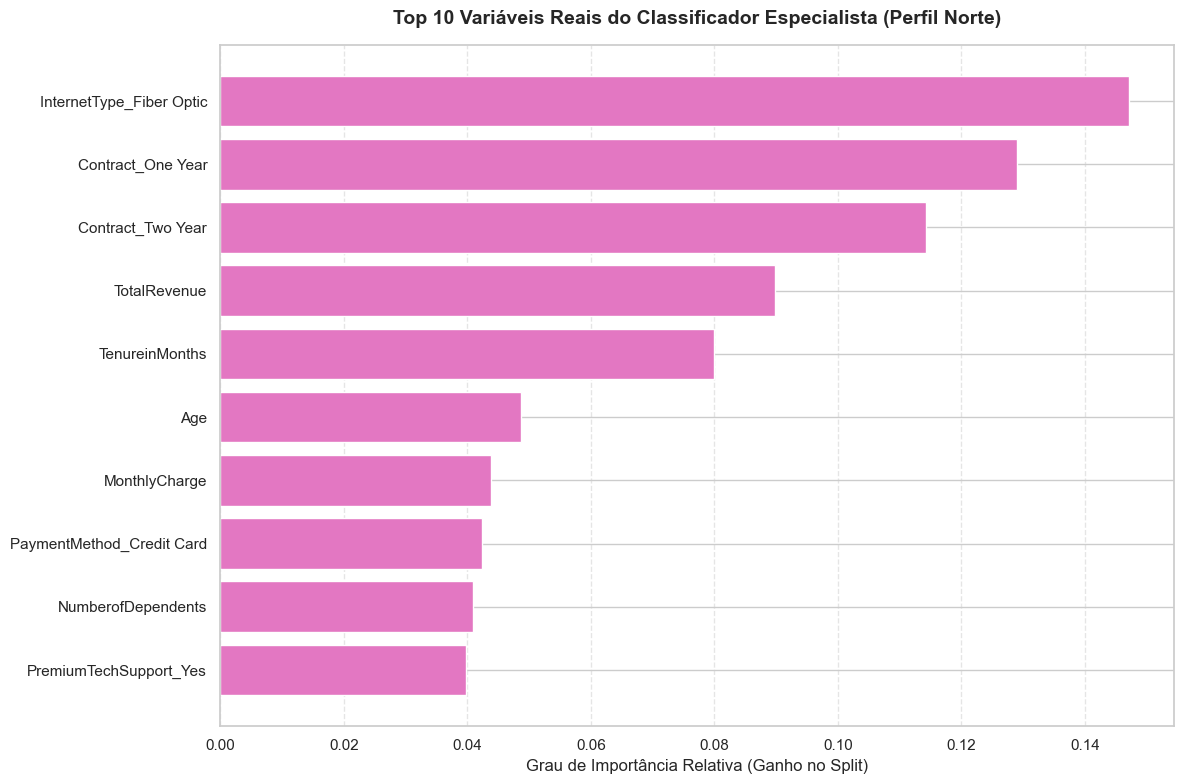

--- Variáveis mais importantes para o Perfil Norte ---
                     Feature  Importance
29  InternetType_Fiber Optic    0.147060
38         Contract_One Year    0.129026
39         Contract_Two Year    0.114330
12              TotalRevenue    0.089864
4             TenureinMonths    0.079856


In [85]:
# 1. Coletar a importância das features do modelo especialista
importances_esp = best_xgb_norte.feature_importances_
feature_names_esp = X_train.columns

# 2. Criar o DataFrame estruturado
df_importances_esp = pd.DataFrame({
    'Feature': feature_names_esp,
    'Importance': importances_esp
}).sort_values(by='Importance', ascending=False)

# 3. Plotar o Top 10 do Especialista
plt.figure(figsize=(12, 8))
plt.barh(df_importances_esp['Feature'].head(10)[::-1], df_importances_esp['Importance'].head(10)[::-1], color='#e377c2') # Rosa para o especialista
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis Reais do Classificador Especialista (Perfil Norte)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- Variáveis mais importantes para o Perfil Norte ---")
print(df_importances_esp.head(5))

--- 1. Matriz de Correlação Linear (Pearson) das Numéricas do Especialista ---
Target_Churn                     1.000000
MonthlyCharge                    0.247598
Age                              0.107844
Population                       0.074256
AvgMonthlyGBDownload             0.067003
AvgMonthlyLongDistanceCharges    0.039548
TotalExtraDataCharges           -0.006461
TotalRefunds                    -0.036607
NumberofReferrals               -0.054006
CLTV                            -0.094087
NumberofDependents              -0.130544
TotalCharges                    -0.166471
TotalRevenue                    -0.187220
TotalLongDistanceCharges        -0.196106
TenureinMonths                  -0.299723
Name: Target_Churn, dtype: float64

--- 2. Associação Categórica (Cramer's V) no Perfil Norte ---
                      Cramer_V
Contract              0.333891
Offer                 0.263873
InternetService       0.257802
InternetType          0.234858
PaperlessBilling      0.213854
Unlimit

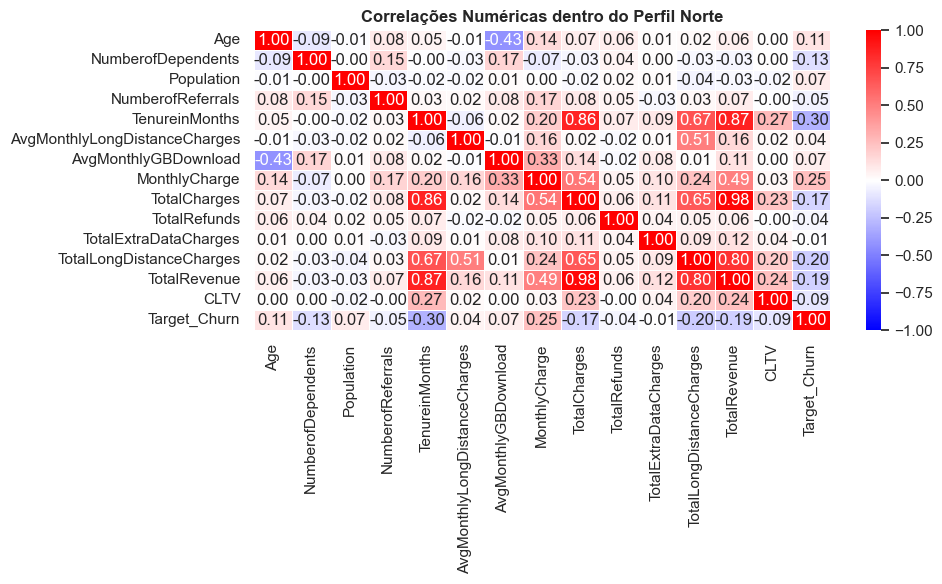

In [86]:
print("--- 1. Matriz de Correlação Linear (Pearson) das Numéricas do Especialista ---")

# Filtrando as colunas numéricas puras da matriz X_train (dummies de texto não entram aqui)
# Identificamos colunas numéricas olhando o DataFrame original antes do get_dummies
cols_num_especialista = [c for c in cols_numericas if c in X_train.columns]

# Adicionamos o y_train temporariamente para ver a correlação direta com o Churn do Norte
df_corr_esp = X_train[cols_num_especialista].copy()
df_corr_esp['Target_Churn'] = y_train

matriz_corr_esp = df_corr_esp.corr()
print(matriz_corr_esp['Target_Churn'].sort_values(ascending=False))

# --- 2. Cramer's V das Categóricas Estruturais do Perfil Norte ---
print("\n--- 2. Associação Categórica (Cramer's V) no Perfil Norte ---")

def cramers_v_local(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0: return 0
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1)) if n > 1 else phi2
    rcorr = r - ((r-1)**2)/(n-1) if n > 1 else r
    kcorr = k - ((k-1)**2)/(n-1) if n > 1 else k
    if min((kcorr-1), (rcorr-1)) == 0: return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Usamos o df_perfil_norte original para pegar as colunas de texto antes do encoding
resultados_cramer_local = {}
for col in cols_cat_norte:
    # Calcula o Cramer's V em relação ao status real de quem está no norte
    status_norte = df_perfil_norte.loc[X_train.index, 'CustomerStatus']
    resultados_cramer_local[col] = cramers_v_local(df_perfil_norte.loc[X_train.index, col], status_norte)

df_cramer_local = pd.DataFrame.from_dict(resultados_cramer_local, orient='index', columns=['Cramer_V']).sort_values(by='Cramer_V', ascending=False)
print(df_cramer_local)

# 3. Plotando o Heatmap de Correlação Numérica
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_corr_esp, annot=True, cmap='bwr', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlações Numéricas dentro do Perfil Norte', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [91]:
print("--- 1. Aplicando Engenharia de Features Local + Efeito Geográfico ---")

# Criando as novas features com base no df_perfil_norte isolado
df_norte_fe = df_perfil_norte.copy()

# Feature Geográfica do seu insight original do Kohonen
df_norte_fe['San_Diego_Effect'] = np.where(df_norte_fe['City'] == 'San Diego', 1, 0)

# =========================================================================
# 2. PREPARAÇÃO DA MATRIZ DO MODELO EVOLUÍDO
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity', 'X_som', 'Y_som'
]

X_norte_fe = df_norte_fe.drop(columns=vazamentos_e_ruidos)
y_norte_fe = np.where(df_norte_fe['CustomerStatus'] == 'Churned', 1, 0)

# Encoding das categóricas
cols_cat_fe = X_norte_fe.select_dtypes(include=['object', 'category']).columns.tolist()
X_norte_fe_encoded = pd.get_dummies(X_norte_fe, columns=cols_cat_fe, drop_first=True)

# Divisão de Treino e Teste (70/30) mantendo o mesmo random_state para comparação justa
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_norte_fe_encoded, y_norte_fe, test_size=0.3, random_state=42, stratify=y_norte_fe
)

# =========================================================================
# 3. NOVO GRIDSEARCH COM VALIDAÇÃO CRUZADA (5-FOLD)
# =========================================================================
print("\n--- 2. Executando Novo GridSearch com as Features de Engenharia ---")

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'gamma': [1, 2, 3]
}

proporcao_classes = (len(y_train_fe) - sum(y_train_fe)) / sum(y_train_fe)
xgb_base_fe = XGBClassifier(scale_pos_weight=proporcao_classes, eval_metric='logloss', random_state=42)

grid_search_fe = GridSearchCV(
    estimator=xgb_base_fe, param_grid=param_grid, scoring='recall', cv=5, verbose=0, n_jobs=-1
)
grid_search_fe.fit(X_train_fe, y_train_fe)

# =========================================================================
# 4. PERFORMANCE NO TESTE CEGO
# =========================================================================
best_xgb_fe = grid_search_fe.best_estimator_
y_pred_fe = best_xgb_fe.predict(X_test_fe)
y_prob_fe = best_xgb_fe.predict_proba(X_test_fe)[:, 1]

print("\n=================== PERFORMANCE DO MODELO COM ENGENHARIA LOCAL ===================")
print(f"Melhores parâmetros: {grid_search_fe.best_params_}")
print(f"ROC-AUC Atualizado: {roc_auc_score(y_test_fe, y_prob_fe)*100:.2f}%")
print(f"RECALL Atualizado: {recall_score(y_test_fe, y_pred_fe)*100:.2f}%")
print(f"PRECISÃO Atualizada: {precision_score(y_test_fe, y_pred_fe)*100:.2f}%")

print("\nNova Matriz de Confusão:")
cm_fe = confusion_matrix(y_test_fe, y_pred_fe)
print(f"  [Clientes do Norte que FICARAM previstos corretamente]: {cm_fe[0][0]}")
print(f"  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: {cm_fe[0][1]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM e cometeu Erro Crítico]: {cm_fe[1][0]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: {cm_fe[1][1]}")

--- 1. Aplicando Engenharia de Features Local + Efeito Geográfico ---

--- 2. Executando Novo GridSearch com as Features de Engenharia ---

=================== PERFORMANCE DO MODELO COM ENGENHARIA LOCAL ===================
Melhores parâmetros: {'gamma': 2, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
ROC-AUC Atualizado: 87.28%
RECALL Atualizado: 81.25%
PRECISÃO Atualizada: 68.67%

Nova Matriz de Confusão:
  [Clientes do Norte que FICARAM previstos corretamente]: 580
  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: 172
  [Clientes do Norte que REALMENTE CANCELARAM e cometeu Erro Crítico]: 87
  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: 377


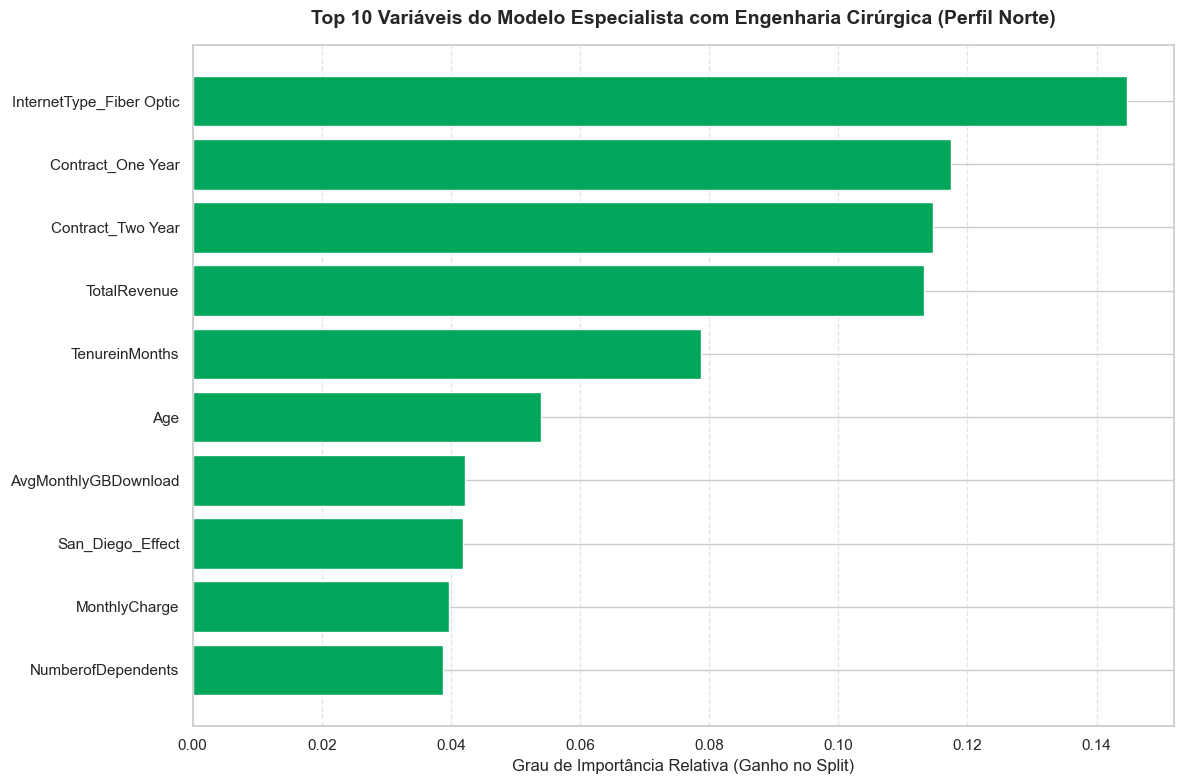

--- Top 5 Variáveis do Modelo Vencedor ---
                     Feature  Importance
30  InternetType_Fiber Optic    0.144753
39         Contract_One Year    0.117501
40         Contract_Two Year    0.114662
12              TotalRevenue    0.113307
4             TenureinMonths    0.078747


In [92]:
# 1. Coletar a importância das features do modelo vencedor com engenharia cirúrgica
importances_otimizado = best_xgb_fe.feature_importances_
feature_names_otimizado = X_train_fe.columns

# 2. Criar o DataFrame estruturado para ordenação
df_importances_otimizado = pd.DataFrame({
    'Feature': feature_names_otimizado,
    'Importance': importances_otimizado
}).sort_values(by='Importance', ascending=False)

# 3. Plotar o Top 10 Definitivo do Especialista
plt.figure(figsize=(12, 8))
plt.barh(df_importances_otimizado['Feature'].head(10)[::-1], df_importances_otimizado['Importance'].head(10)[::-1], color='#00a65a') # Verde operacional
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis do Modelo Especialista com Engenharia Cirúrgica (Perfil Norte)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- Top 5 Variáveis do Modelo Vencedor ---")
print(df_importances_otimizado.head(5))